In [24]:
%pip install -q ultralytics opencv-python matplotlib numpy pandas pyyaml tqdm


Note: you may need to restart the kernel to use updated packages.


# Lab 3: Road Sign Segmentation and Tracking

In [25]:
%matplotlib inline

import json
import random
import shutil
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image as IPyImage, Video as IPyVideo, display
from tqdm.auto import tqdm
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CWD = Path.cwd().resolve()
LAB_DIR = CWD if CWD.name == "lab3" else CWD / "lab3"
PROJECT_ROOT = LAB_DIR.parent

RAW_DATA_DIR = LAB_DIR / "data" / "raw"
DATASET_DIR = RAW_DATA_DIR / "sign_dataset"
YOLO_DATA_DIR = LAB_DIR / "data" / "yolo_rtsd_seg"
RUNS_DIR = LAB_DIR / "runs"
VIDEOS_DIR = LAB_DIR / "videos"
STREET_PHOTOS_DIR = LAB_DIR / "street_photos"
PHOTO_PREDICTIONS_DIR = LAB_DIR / "predictions"
TRACKING_DIR = LAB_DIR / "tracking_eval"

VIDEO_SOURCE_DIR = VIDEOS_DIR / "raw"
VIDEO_PRED_DIR = VIDEOS_DIR / "predictions"
GT_TRACKS_DIR = TRACKING_DIR / "gt"
PRED_TRACKS_DIR = TRACKING_DIR / "pred"

for path in [RAW_DATA_DIR, YOLO_DATA_DIR, RUNS_DIR, VIDEO_SOURCE_DIR, STREET_PHOTOS_DIR, PHOTO_PREDICTIONS_DIR, GT_TRACKS_DIR, PRED_TRACKS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {CWD}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Lab directory: {LAB_DIR}")
print(f"Dataset directory: {DATASET_DIR}")


Working directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3
Project root: /Users/brrdlam/ct-itmo/ct-computer-vision
Lab directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3
Dataset directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3/data/raw/sign_dataset


## Подготовка Датасета

In [26]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def list_images(root: Path) -> List[Path]:
    return sorted([p for p in root.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS], key=lambda p: str(p))


def shape_to_points(shape: Dict[str, object]) -> np.ndarray:
    shape_name = shape["name"]

    if shape_name == "polygon":
        return np.column_stack([shape["all_points_x"], shape["all_points_y"]]).astype(np.float32)

    if shape_name == "rect":
        x = float(shape["x"])
        y = float(shape["y"])
        w = float(shape["width"])
        h = float(shape["height"])
        return np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], dtype=np.float32)

    if shape_name == "circle":
        t = np.linspace(0, 2 * np.pi, 24, endpoint=False)
        cx = float(shape["cx"])
        cy = float(shape["cy"])
        r = float(shape["r"])
        x = cx + r * np.cos(t)
        y = cy + r * np.sin(t)
        return np.column_stack([x, y]).astype(np.float32)

    t = np.linspace(0, 2 * np.pi, 24, endpoint=False)
    cx = float(shape["cx"])
    cy = float(shape["cy"])
    rx = float(shape["rx"])
    ry = float(shape["ry"])
    x = cx + rx * np.cos(t)
    y = cy + ry * np.sin(t)
    return np.column_stack([x, y]).astype(np.float32)


shutil.rmtree(YOLO_DATA_DIR, ignore_errors=True)

for split in ["train", "val"]:
    (YOLO_DATA_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_DATA_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

    image_dir = DATASET_DIR / split
    image_paths = list_images(image_dir)
    via_data = json.loads((image_dir / "via_region_data.json").read_text(encoding="utf-8"))
    annotations = {item["filename"]: item for item in via_data.values()}

    for image_path in tqdm(image_paths, desc=f"convert {split}"):
        image = cv2.imread(str(image_path))
        height, width = image.shape[:2]
        shutil.copy2(image_path, YOLO_DATA_DIR / split / "images" / image_path.name)

        lines = []
        for region in annotations[image_path.name]["regions"].values():
            if region["region_attributes"].get("name") != "road sign":
                continue

            points = shape_to_points(region["shape_attributes"])
            points[:, 0] = np.clip(points[:, 0] / width, 0.0, 1.0)
            points[:, 1] = np.clip(points[:, 1] / height, 0.0, 1.0)
            coords = " ".join(f"{value:.6f}" for value in points.reshape(-1))
            lines.append(f"0 {coords}")

        (YOLO_DATA_DIR / split / "labels" / f"{image_path.stem}.txt").write_text("\n".join(lines), encoding="utf-8")

YOLO_DATA_YAML = YOLO_DATA_DIR / "data.yaml"
YOLO_DATA_YAML.write_text(
    yaml.safe_dump(
        {
            "path": str(YOLO_DATA_DIR.resolve()),
            "train": "train/images",
            "val": "val/images",
            "names": ["road_sign"],
        },
        sort_keys=False,
        allow_unicode=True,
    ),
    encoding="utf-8",
)

dataset_summary = {
    "dataset_location": str(YOLO_DATA_DIR),
    "data_yaml": str(YOLO_DATA_YAML),
    "train_images": len(list_images(YOLO_DATA_DIR / "train" / "images")),
    "valid_images": len(list_images(YOLO_DATA_DIR / "val" / "images")),
    "classes": ["road_sign"],
}
print(json.dumps(dataset_summary, indent=2, ensure_ascii=False))


convert val: 100%|██████████| 127/127 [00:00<00:00, 186.69it/s]

{
  "dataset_location": "/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/data/yolo_rtsd_seg",
  "data_yaml": "/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/data/yolo_rtsd_seg/data.yaml",
  "train_images": 2054,
  "valid_images": 127,
  "classes": [
    "road_sign"
  ]
}


## Обучение Модели

Запуск обучения YOLO11-seg на подготовленном датасете.

In [27]:
MODEL_NAME = "yolo11n-seg.pt"
RUN_NAME = "yolo11n_seg_russian_signs_local"
BEST_WEIGHTS = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

TRAIN_EPOCHS = 10
TRAIN_IMGSZ = 512
TRAIN_BATCH = 32

model = YOLO(MODEL_NAME)
train_results = model.train(
    data=str(YOLO_DATA_YAML),
    epochs=TRAIN_EPOCHS,
    imgsz=TRAIN_IMGSZ,
    batch=TRAIN_BATCH,
    device="mps",
    optimizer="AdamW",
    lr0=1e-3,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    fliplr=0.5,
    degrees=5.0,
    translate=0.05,
    scale=0.15,
)
print(train_results)


New https://pypi.org/project/ultralytics/8.4.19 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.13.1 torch-2.10.0 MPS (Apple M2 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/data/yolo_rtsd_seg/data.yaml, degrees=5.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, mu

## Валидация

Подсчет метрик качества на валидационной выборке.

In [29]:
def load_class_names(data_yaml_path: Path) -> List[str]:
    data_cfg = yaml.safe_load(data_yaml_path.read_text(encoding="utf-8"))
    names = data_cfg["names"]
    if isinstance(names, list):
        return names
    return [names[idx] for idx in sorted(names)]


def load_gt_masks(label_path: Path, image_shape: Tuple[int, int], num_classes: int) -> List[np.ndarray]:
    height, width = image_shape
    masks = [np.zeros((height, width), dtype=np.uint8) for _ in range(num_classes)]
    for raw_line in label_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            continue
        values = line.split()
        class_id = int(values[0])
        coords = np.array(values[1:], dtype=np.float32).reshape(-1, 2)
        polygon = np.zeros((coords.shape[0], 2), dtype=np.int32)
        polygon[:, 0] = np.clip(np.round(coords[:, 0] * (width - 1)), 0, width - 1).astype(np.int32)
        polygon[:, 1] = np.clip(np.round(coords[:, 1] * (height - 1)), 0, height - 1).astype(np.int32)
        cv2.fillPoly(masks[class_id], [polygon], 1)
    return masks


def load_pred_masks(result, image_shape: Tuple[int, int], num_classes: int, conf_threshold: float) -> List[np.ndarray]:
    height, width = image_shape
    masks = [np.zeros((height, width), dtype=np.uint8) for _ in range(num_classes)]
    if result.masks is None or result.boxes is None or len(result.boxes) == 0:
        return masks

    raw_masks = result.masks.data.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    scores = result.boxes.conf.cpu().numpy()

    for mask, class_id, score in zip(raw_masks, classes, scores):
        if score < conf_threshold:
            continue
        binary = (mask > 0.5).astype(np.uint8)
        if binary.shape != (height, width):
            binary = cv2.resize(binary, (width, height), interpolation=cv2.INTER_NEAREST)
            binary = (binary > 0).astype(np.uint8)
        masks[class_id] = np.maximum(masks[class_id], binary)
    return masks


def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def binary_iou(gt_mask: np.ndarray, pred_mask: np.ndarray) -> float:
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    return safe_div(float(intersection), float(union))


def binary_precision(gt_mask: np.ndarray, pred_mask: np.ndarray) -> float:
    tp = np.logical_and(gt_mask, pred_mask).sum()
    fp = np.logical_and(np.logical_not(gt_mask), pred_mask).sum()
    return safe_div(float(tp), float(tp + fp))


def binary_recall(gt_mask: np.ndarray, pred_mask: np.ndarray) -> float:
    tp = np.logical_and(gt_mask, pred_mask).sum()
    fn = np.logical_and(gt_mask, np.logical_not(pred_mask)).sum()
    return safe_div(float(tp), float(tp + fn))


def binary_l2(gt_mask: np.ndarray, pred_mask: np.ndarray) -> float:
    diff = gt_mask.astype(np.float32) - pred_mask.astype(np.float32)
    return float(np.linalg.norm(diff) / np.sqrt(diff.size))


def evaluate_segmentation(weights_path: Path, data_root: Path, split: str = "val", conf_threshold: float = 0.25):
    data_yaml_path = data_root / "data.yaml"
    data_cfg = yaml.safe_load(data_yaml_path.read_text(encoding="utf-8"))
    class_names = load_class_names(data_yaml_path)
    num_classes = len(class_names)
    split_key = "val" if split == "val" else split
    image_dir = data_root / Path(data_cfg[split_key])
    label_dir = image_dir.parent / "labels"
    image_paths = sorted([p for p in image_dir.iterdir() if p.is_file()], key=lambda p: str(p))

    model = YOLO(str(weights_path))
    class_rows = []
    image_rows = []

    for image_path in tqdm(image_paths, desc=f"Evaluating {split}"):
        image = cv2.imread(str(image_path))
        height, width = image.shape[:2]
        label_path = label_dir / f"{image_path.stem}.txt"
        gt_masks = load_gt_masks(label_path, (height, width), num_classes)
        result = model.predict(source=str(image_path), conf=conf_threshold, verbose=False)[0]
        pred_masks = load_pred_masks(result, (height, width), num_classes, conf_threshold)

        image_gt = np.zeros((height, width), dtype=np.uint8)
        image_pred = np.zeros((height, width), dtype=np.uint8)

        for class_id, class_name in enumerate(class_names):
            gt_mask = gt_masks[class_id]
            pred_mask = pred_masks[class_id]
            image_gt = np.maximum(image_gt, gt_mask)
            image_pred = np.maximum(image_pred, pred_mask)
            class_rows.append({
                "image_name": image_path.name,
                "class_name": class_name,
                "iou": binary_iou(gt_mask, pred_mask),
                "precision": binary_precision(gt_mask, pred_mask),
                "recall": binary_recall(gt_mask, pred_mask),
                "l2": binary_l2(gt_mask, pred_mask),
            })

        image_rows.append({
            "image_name": image_path.name,
            "iou": binary_iou(image_gt, image_pred),
            "precision": binary_precision(image_gt, image_pred),
            "recall": binary_recall(image_gt, image_pred),
            "l2": binary_l2(image_gt, image_pred),
        })

    class_df = pd.DataFrame(class_rows)
    image_df = pd.DataFrame(image_rows)
    per_class_df = (
        class_df.groupby("class_name", as_index=False)[["iou", "precision", "recall", "l2"]]
        .mean()
        .rename(columns={"iou": "mean_iou", "precision": "mean_precision", "recall": "mean_recall", "l2": "mean_l2"})
        .sort_values("mean_iou", ascending=False)
        .reset_index(drop=True)
    )

    summary = {
        "split": split,
        "images": int(len(image_df)),
        "mean_iou": float(image_df["iou"].mean()),
        "mean_precision": float(image_df["precision"].mean()),
        "mean_recall": float(image_df["recall"].mean()),
        "mean_l2": float(image_df["l2"].mean()),
        "iou_ge_0_5": float((image_df["iou"] >= 0.5).mean()),
        "iou_ge_0_75": float((image_df["iou"] >= 0.75).mean()),
        "iou_ge_0_9": float((image_df["iou"] >= 0.9).mean()),
    }
    return summary, per_class_df, image_df


summary, per_class_metrics, per_image_metrics = evaluate_segmentation(BEST_WEIGHTS, YOLO_DATA_DIR, split="val", conf_threshold=0.25)
print(json.dumps(summary, indent=2))
display(per_class_metrics)
display(per_image_metrics.head())


Evaluating val: 100%|██████████| 127/127 [00:06<00:00, 20.25it/s]

{
  "split": "val",
  "images": 127,
  "mean_iou": 0.5147597181097358,
  "mean_precision": 0.5563507328977031,
  "mean_recall": 0.8777278212635174,
  "mean_l2": 0.06360629673490142,
  "iou_ge_0_5": 0.5590551181102362,
  "iou_ge_0_75": 0.047244094488188976,
  "iou_ge_0_9": 0.0
}


,class_name,mean_iou,mean_precision,mean_recall,mean_l2
0,road_sign,0.51476,0.556351,0.877728,0.063606


,image_name,iou,precision,recall,l2
0,201.jpg,0.703134,0.794846,0.859034,0.097082
1,202.jpg,0.832531,0.838718,0.991217,0.097889
2,203.jpg,0.686706,0.810577,0.817970,0.064600
3,204.jpg,0.620106,0.717287,0.820690,0.077399
4,205.jpg,0.473734,0.507602,0.876546,0.060993


## Инференс

Проверка модели на уличных фото, видео и сравнение двух трекеров.

Using weights: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3/runs/yolo11n_seg_russian_signs_local/weights/best.pt
Model classes: {0: 'road_sign'}
Reading photos from: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3/street_photos
Saving predictions to: /Users/brrdlam/ct-itmo/ct-computer-vision/lab3/predictions


,image_name,class_id,class_name,confidence
0,1.jpg,0,road_sign,0.745306
1,1.jpg,0,road_sign,0.576997
2,1.jpg,0,road_sign,0.532401
3,1.jpg,0,road_sign,0.496114
4,2.jpg,0,road_sign,0.942812
5,2.jpg,0,road_sign,0.839764
6,2.jpg,0,road_sign,0.709448
7,2.jpg,0,road_sign,0.657992
8,2.jpg,0,road_sign,0.643951
9,2.jpg,0,road_sign,0.534611



Предсказанные изображения:
1.jpg


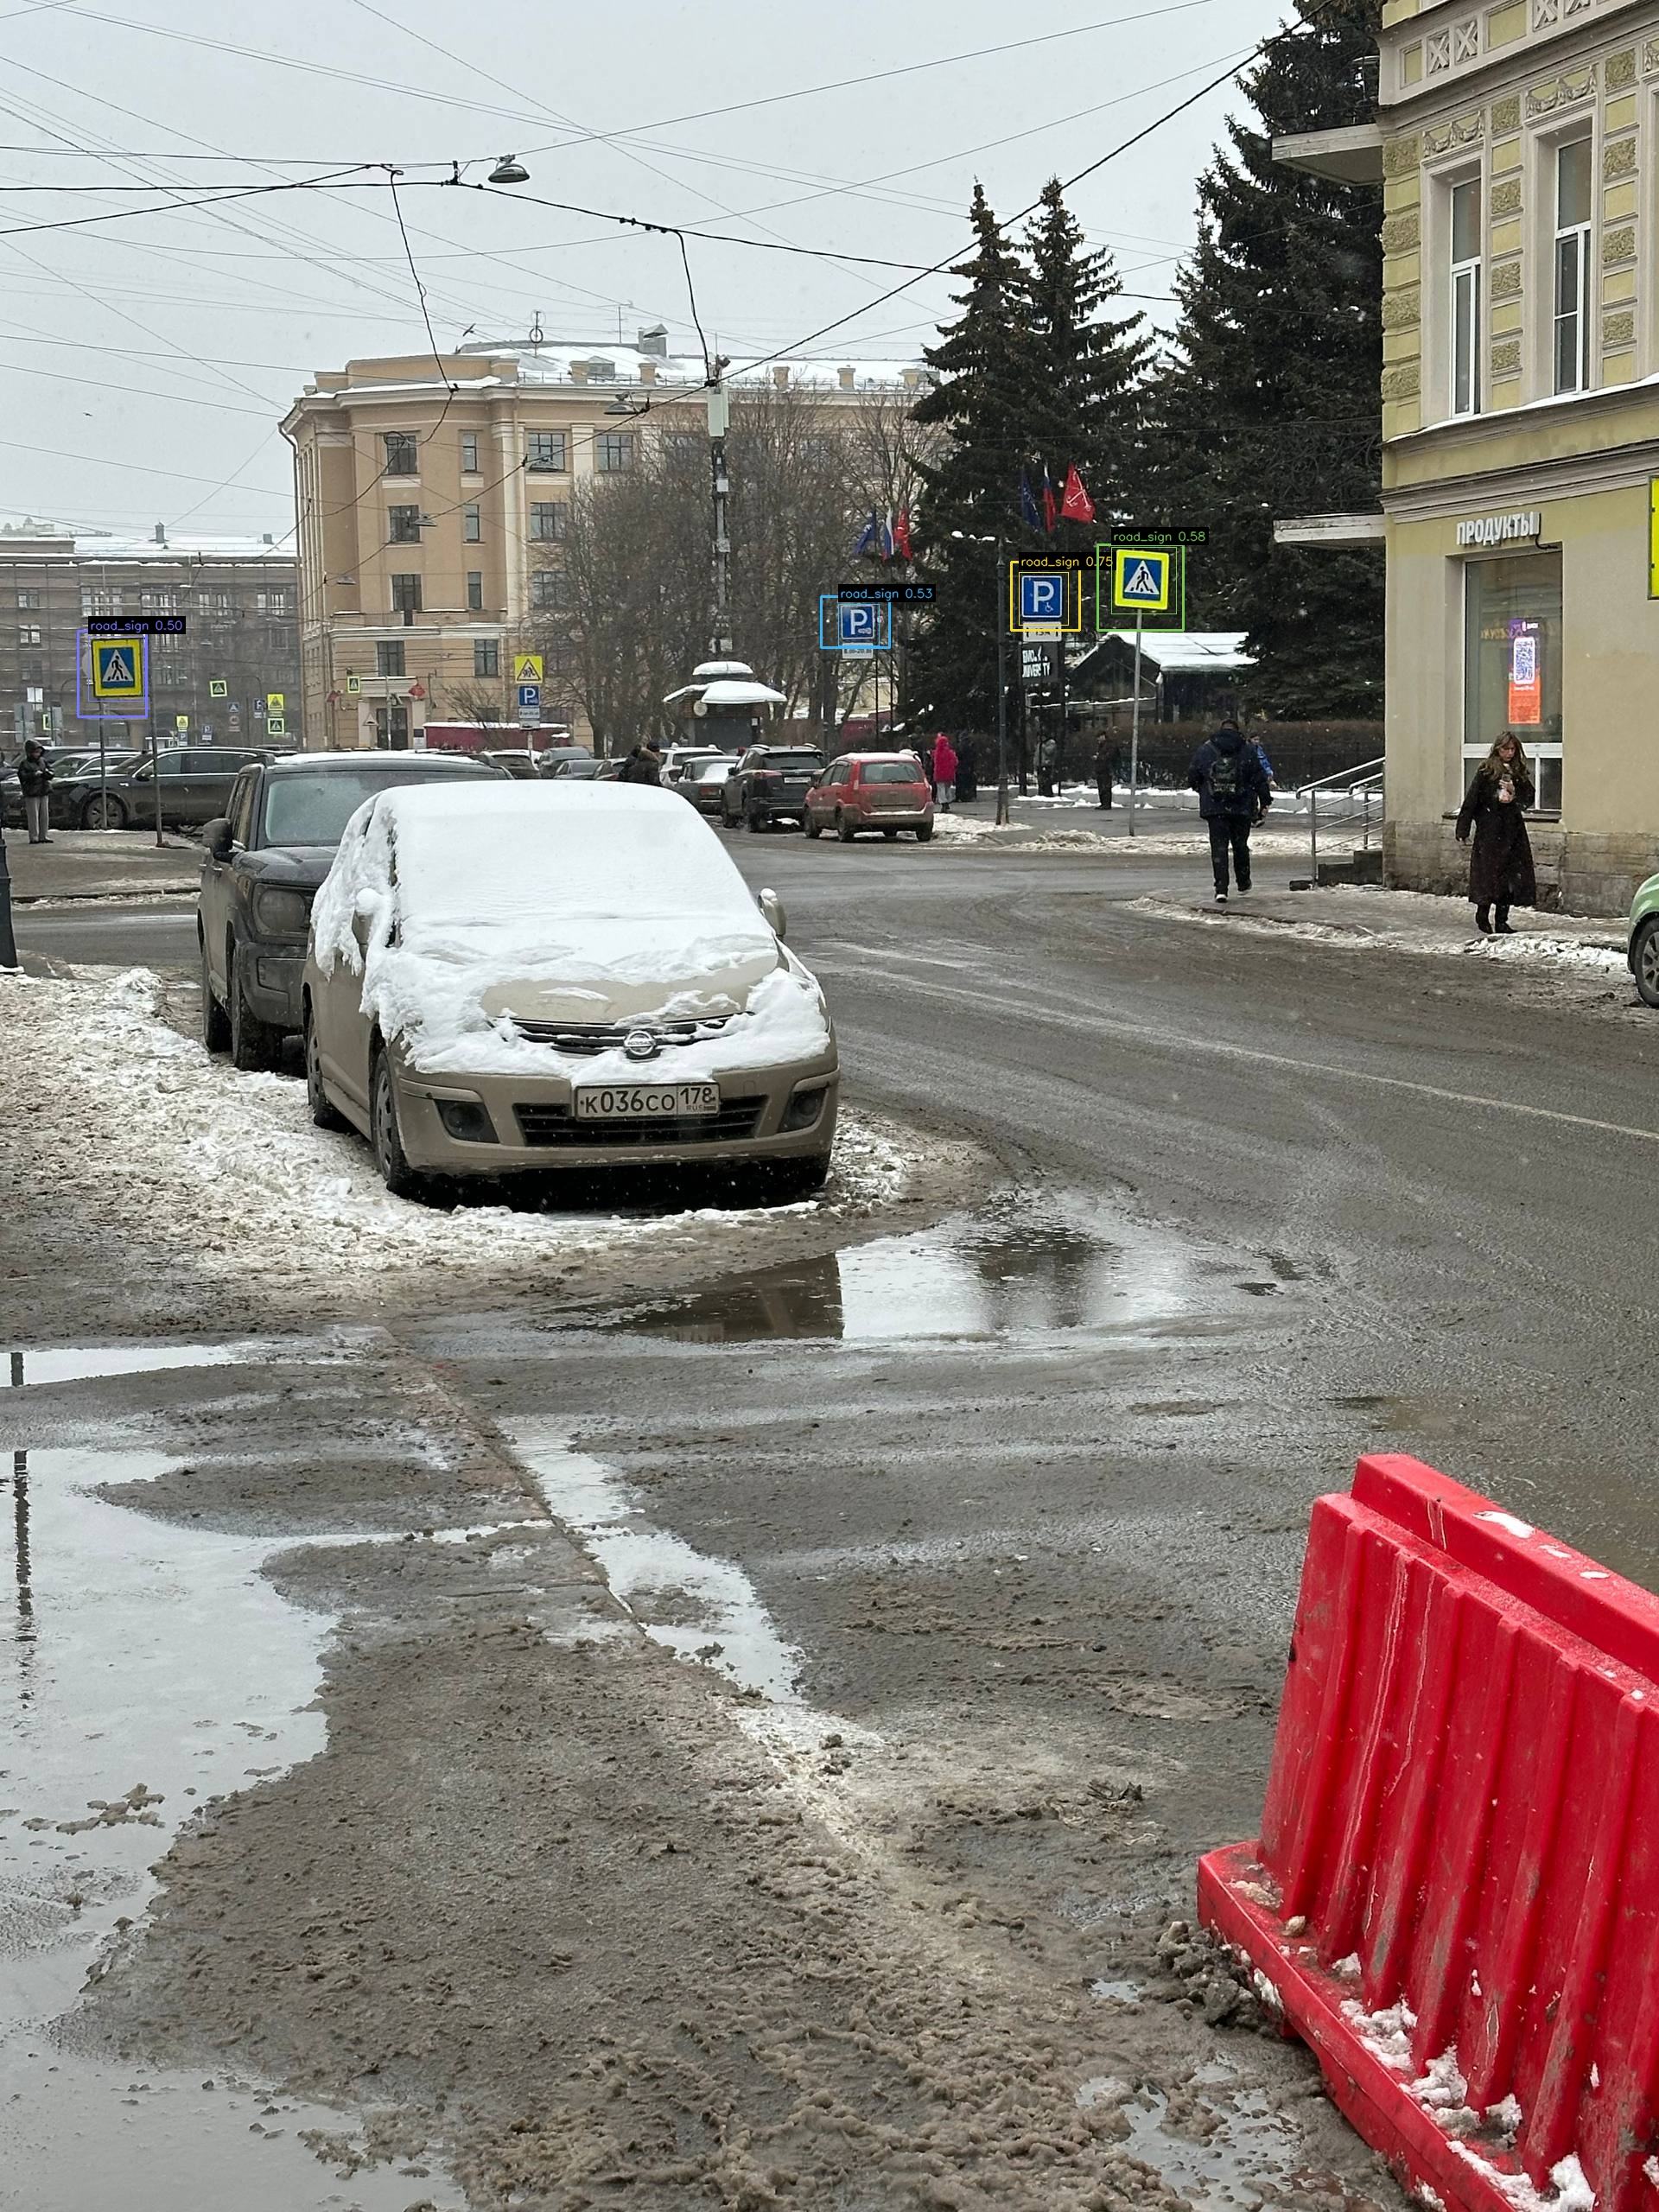

2.jpg


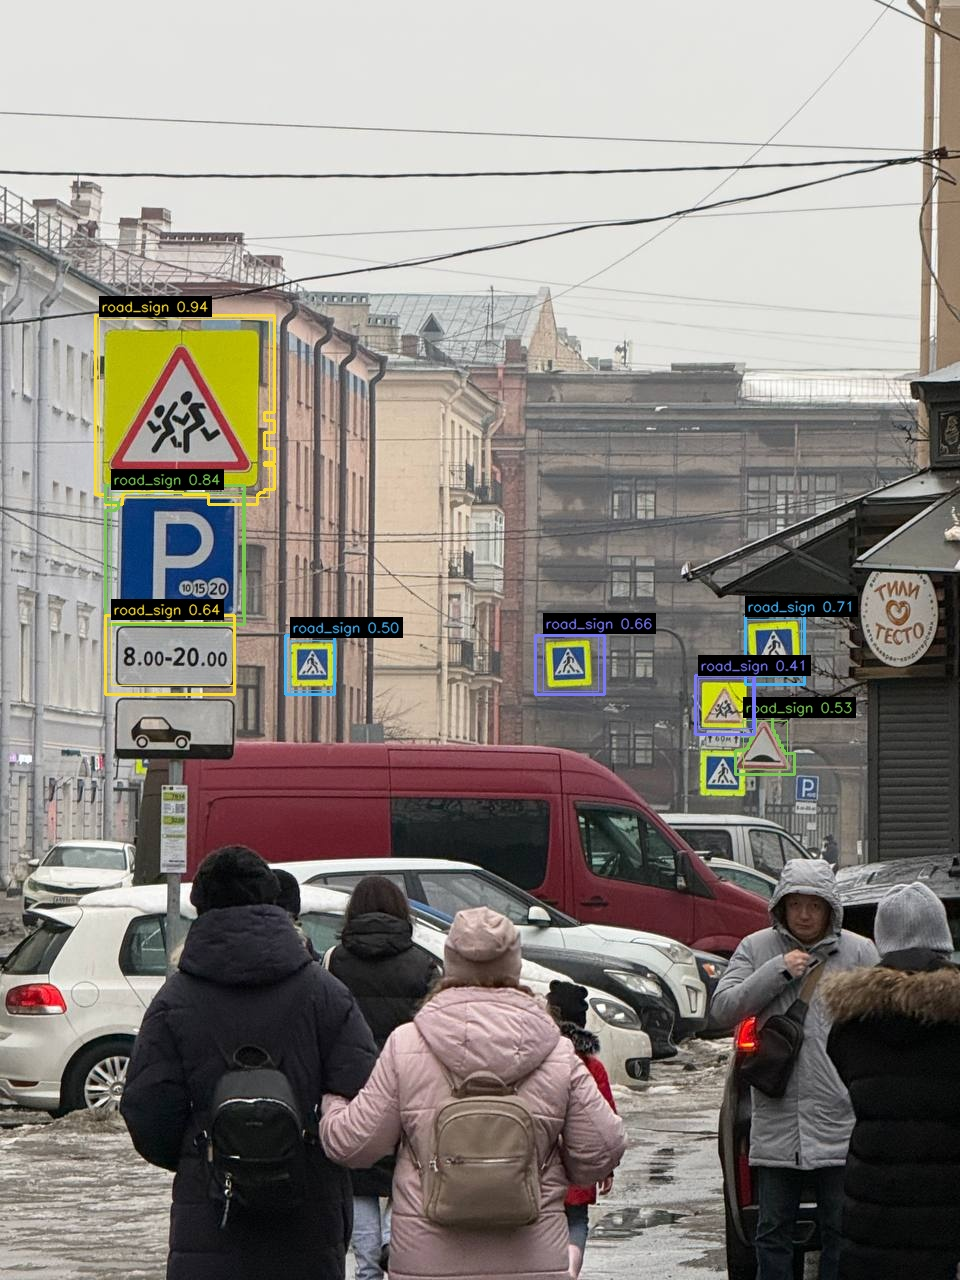

3.jpg


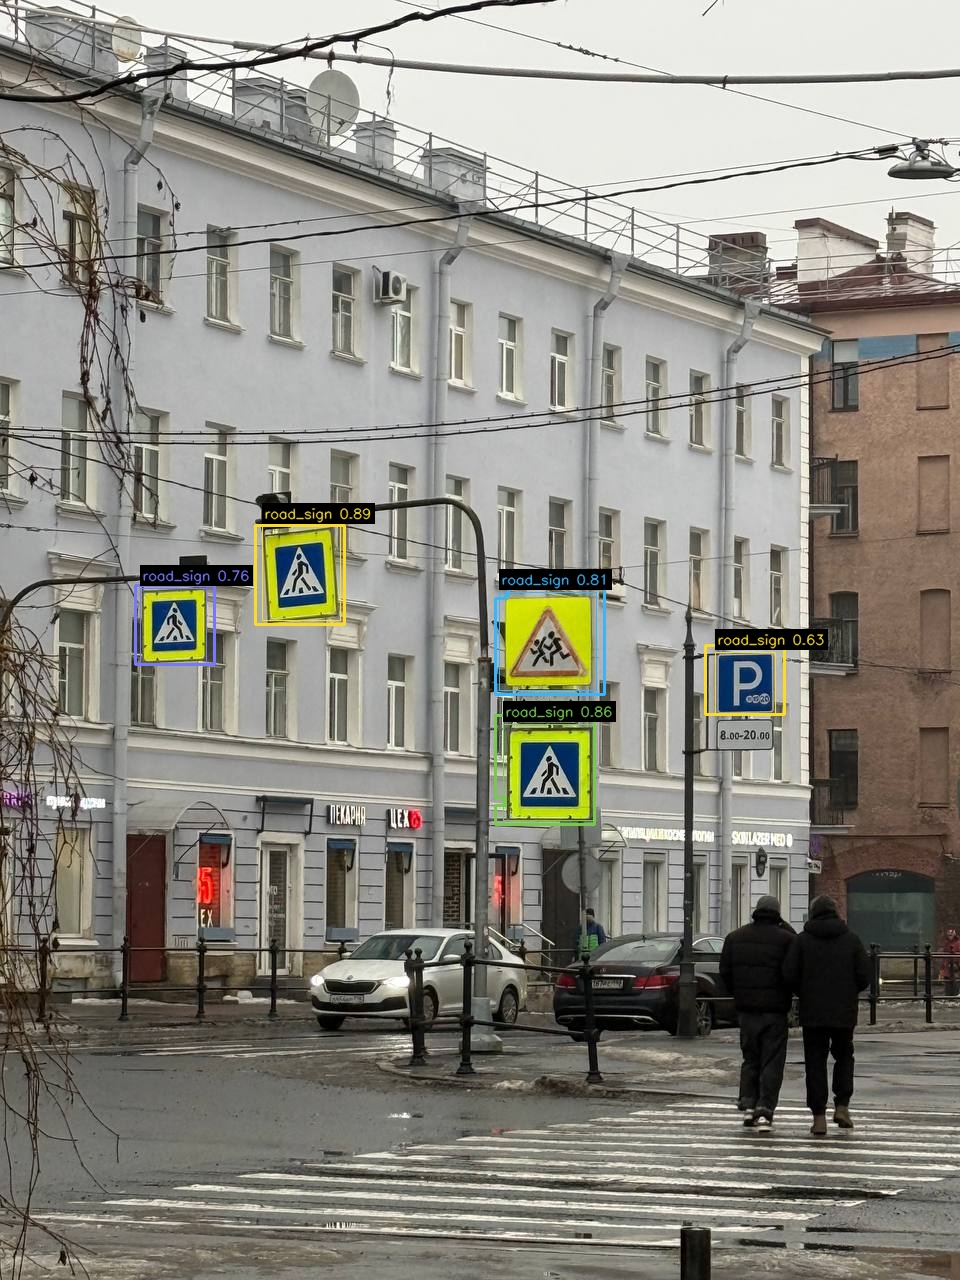

In [30]:
PHOTO_WEIGHTS = BEST_WEIGHTS
PHOTO_SOURCE_DIR = STREET_PHOTOS_DIR
PHOTO_OUTPUT_DIR = PHOTO_PREDICTIONS_DIR
PREDICT_CONF = 0.35


def render_prediction_frame(result, class_names: Optional[List[str]] = None) -> np.ndarray:
    frame = result.orig_img.copy()

    if result.boxes is None or len(result.boxes) == 0:
        return frame

    boxes = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    scores = result.boxes.conf.cpu().numpy()
    masks = result.masks.data.cpu().numpy() if result.masks is not None else None
    colors = [
        (40, 220, 250),
        (80, 200, 120),
        (250, 180, 60),
        (255, 120, 120),
    ]

    for idx, (box, class_id, score) in enumerate(zip(boxes, classes, scores)):
        color = colors[idx % len(colors)]
        x1, y1, x2, y2 = np.round(box).astype(int).tolist()
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(frame.shape[1] - 1, x2)
        y2 = min(frame.shape[0] - 1, y2)

        if masks is not None:
            mask = (masks[idx] > 0.5).astype(np.uint8)
            if mask.shape[:2] != frame.shape[:2]:
                mask = cv2.resize(mask, (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_NEAREST)
                mask = (mask > 0).astype(np.uint8)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(frame, contours, -1, color, 2)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 1)

        if class_names is not None and 0 <= class_id < len(class_names):
            class_name = class_names[class_id]
        else:
            class_name = f"class_{class_id}"
        label = f"{class_name} {score:.2f}"

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.45
        thickness = 1
        (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        text_x = x1
        text_y = y1 - 6 if y1 - 6 > text_h else min(frame.shape[0] - 4, y1 + text_h + 6)
        box_y1 = max(0, text_y - text_h - baseline - 2)
        box_y2 = min(frame.shape[0] - 1, text_y + baseline - 2)
        box_x2 = min(frame.shape[1] - 1, text_x + text_w + 4)
        cv2.rectangle(frame, (text_x, box_y1), (box_x2, box_y2), (0, 0, 0), -1)
        cv2.putText(frame, label, (text_x + 2, text_y - 2), font, font_scale, color, thickness, cv2.LINE_AA)

    return frame


def predict_street_photos(weights_path: Path, source_dir: Path, output_dir: Path, data_yaml_path: Optional[Path] = None, conf_threshold: float = 0.25):
    image_paths = list_images(source_dir)
    class_names = load_class_names(data_yaml_path) if data_yaml_path is not None else None

    output_dir.mkdir(parents=True, exist_ok=True)
    model = YOLO(str(weights_path))
    print(f"Using weights: {weights_path}")
    print(f"Model classes: {model.names}")
    print(f"Reading photos from: {source_dir}")
    print(f"Saving predictions to: {output_dir}")

    rows = []
    saved_paths: List[Path] = []

    for image_path in image_paths:
        result = model.predict(source=str(image_path), conf=conf_threshold, verbose=False)[0]
        rendered = render_prediction_frame(result, class_names=class_names)
        output_path = output_dir / image_path.name
        cv2.imwrite(str(output_path), rendered)
        saved_paths.append(output_path)

        if result.boxes is None or len(result.boxes) == 0:
            rows.append({
                "image_name": image_path.name,
                "class_id": None,
                "class_name": "<no detections>",
                "confidence": None,
            })
            continue

        classes = result.boxes.cls.cpu().numpy().astype(int)
        scores = result.boxes.conf.cpu().numpy()
        for class_id, score in zip(classes, scores):
            if class_names is not None and 0 <= class_id < len(class_names):
                class_name = class_names[class_id]
            else:
                class_name = f"class_{class_id}"
            rows.append({
                "image_name": image_path.name,
                "class_id": int(class_id),
                "class_name": class_name,
                "confidence": float(score),
            })

    detections_df = pd.DataFrame(rows)
    if not detections_df.empty:
        detections_df = detections_df.sort_values(["image_name", "confidence"], ascending=[True, False], na_position="last").reset_index(drop=True)
        display(detections_df)

    print("\nПредсказанные изображения:")
    for output_path in saved_paths:
        print(output_path.name)
        display(IPyImage(filename=str(output_path)))

    return detections_df, saved_paths


_photo_detections, _photo_outputs = predict_street_photos(
    weights_path=PHOTO_WEIGHTS,
    source_dir=PHOTO_SOURCE_DIR,
    output_dir=PHOTO_OUTPUT_DIR,
    data_yaml_path=YOLO_DATA_DIR / "data.yaml",
    conf_threshold=PREDICT_CONF,
)


In [32]:
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv"}


def list_videos(root: Path) -> List[Path]:
    return sorted([p for p in root.iterdir() if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS], key=lambda p: str(p))


def run_video_inference(weights_path: Path, source_dir: Path, save_dir: Path, conf_threshold: float = 0.25) -> List[Path]:
    model = YOLO(str(weights_path))
    save_dir.mkdir(parents=True, exist_ok=True)
    rendered_dirs: List[Path] = []
    for video_path in list_videos(source_dir):
        model.predict(
            source=str(video_path),
            conf=conf_threshold,
            save=True,
            project=str(save_dir),
            name=video_path.stem,
            exist_ok=True,
            verbose=False,
        )
        rendered_dirs.append(save_dir / video_path.stem)
        print(f"Saved segmented video for {video_path.name}")
    return rendered_dirs


def find_rendered_video_files(rendered_dirs: List[Path]) -> List[Path]:
    video_paths: List[Path] = []
    for rendered_dir in rendered_dirs:
        video_paths.extend(sorted(rendered_dir.rglob("*.mp4"), key=lambda p: str(p)))
    return video_paths


def run_tracker_to_csv(weights_path: Path, source_dir: Path, tracker_name: str, output_dir: Path, conf_threshold: float = 0.25) -> List[Path]:
    model = YOLO(str(weights_path))
    tracker_dir = output_dir / tracker_name.replace(".yaml", "")
    tracker_dir.mkdir(parents=True, exist_ok=True)
    csv_paths: List[Path] = []

    for video_path in list_videos(source_dir):
        rows = []
        results = model.track(
            source=str(video_path),
            tracker=tracker_name,
            conf=conf_threshold,
            stream=True,
            persist=True,
            verbose=False,
        )

        for frame_idx, result in enumerate(results):
            boxes = result.boxes
            if boxes is None or len(boxes) == 0:
                continue

            xyxy = boxes.xyxy.cpu().numpy()
            classes = boxes.cls.cpu().numpy().astype(int) if boxes.cls is not None else np.full(len(xyxy), -1, dtype=int)
            scores = boxes.conf.cpu().numpy() if boxes.conf is not None else np.ones(len(xyxy), dtype=float)
            track_ids = boxes.id.cpu().numpy().astype(int) if boxes.id is not None else np.full(len(xyxy), -1, dtype=int)

            for box, class_id, score, track_id in zip(xyxy, classes, scores, track_ids):
                x1, y1, x2, y2 = box.tolist()
                rows.append({
                    "frame": frame_idx,
                    "track_id": int(track_id),
                    "class_id": int(class_id),
                    "confidence": float(score),
                    "x1": float(x1),
                    "y1": float(y1),
                    "x2": float(x2),
                    "y2": float(y2),
                })

        csv_path = tracker_dir / f"{video_path.stem}_tracks.csv"
        pd.DataFrame(rows).to_csv(csv_path, index=False)
        csv_paths.append(csv_path)
        print(f"Saved {tracker_name} tracks: {csv_path}")

    return csv_paths


def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def box_iou_xyxy(box_a: np.ndarray, box_b: np.ndarray) -> float:
    x1 = max(float(box_a[0]), float(box_b[0]))
    y1 = max(float(box_a[1]), float(box_b[1]))
    x2 = min(float(box_a[2]), float(box_b[2]))
    y2 = min(float(box_a[3]), float(box_b[3]))
    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    intersection = inter_w * inter_h
    area_a = max(0.0, float(box_a[2]) - float(box_a[0])) * max(0.0, float(box_a[3]) - float(box_a[1]))
    area_b = max(0.0, float(box_b[2]) - float(box_b[0])) * max(0.0, float(box_b[3]) - float(box_b[1]))
    union = area_a + area_b - intersection
    return safe_div(intersection, union)


def compute_id_switches(gt_df: pd.DataFrame, pred_df: pd.DataFrame, iou_threshold: float = 0.5) -> int:
    last_assignment: Dict[int, int] = {}
    id_switches = 0
    frame_ids = sorted(set(gt_df["frame"].tolist()) | set(pred_df["frame"].tolist()))

    for frame_id in frame_ids:
        frame_gt = gt_df[gt_df["frame"] == frame_id]
        frame_pred = pred_df[pred_df["frame"] == frame_id]
        if frame_gt.empty or frame_pred.empty:
            continue

        candidates = []
        for gt_row in frame_gt.itertuples(index=False):
            gt_box = np.array([gt_row.x1, gt_row.y1, gt_row.x2, gt_row.y2], dtype=np.float32)
            for pred_row in frame_pred.itertuples(index=False):
                pred_box = np.array([pred_row.x1, pred_row.y1, pred_row.x2, pred_row.y2], dtype=np.float32)
                score = box_iou_xyxy(gt_box, pred_box)
                if score >= iou_threshold:
                    candidates.append((score, int(gt_row.gt_id), int(pred_row.track_id)))

        candidates.sort(reverse=True, key=lambda item: item[0])
        used_gt = set()
        used_pred = set()

        for _, gt_id, pred_id in candidates:
            if gt_id in used_gt or pred_id in used_pred:
                continue
            if gt_id in last_assignment and last_assignment[gt_id] != pred_id:
                id_switches += 1
            last_assignment[gt_id] = pred_id
            used_gt.add(gt_id)
            used_pred.add(pred_id)

    return id_switches


def evaluate_tracking_run(gt_csv: Path, pred_csv: Path, iou_threshold: float = 0.5) -> Dict[str, object]:
    gt_df = pd.read_csv(gt_csv)
    pred_df = pd.read_csv(pred_csv)
    return {
        "gt_csv": str(gt_csv),
        "pred_csv": str(pred_csv),
        "iou_threshold": iou_threshold,
        "id_switches": int(compute_id_switches(gt_df, pred_df, iou_threshold=iou_threshold)),
    }


run_video_inference(BEST_WEIGHTS, VIDEO_SOURCE_DIR, VIDEO_PRED_DIR, conf_threshold=0.25)
for tracker in ("bytetrack.yaml", "botsort.yaml"):
    run_tracker_to_csv(BEST_WEIGHTS, VIDEO_SOURCE_DIR, tracker, PRED_TRACKS_DIR, conf_threshold=0.25)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /Users/brrdlam/ct-itmo/ct-computer-vision/lab3/videos/predictions/1
Saved segmented video for 1.MOV
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:

In [33]:
rendered_dirs = [VIDEO_PRED_DIR / video_path.stem for video_path in list_videos(VIDEO_SOURCE_DIR)]
rendered_videos = find_rendered_video_files(rendered_dirs)

print("Сохраненные видео с предсказаниями:")
for rendered_video in rendered_videos:
    print(rendered_video)
    display(IPyVideo(filename=str(rendered_video), embed=False))


Сохраненные видео с предсказаниями:
/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/videos/predictions/1/1.mp4


/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/videos/predictions/2/2.mp4


/Users/brrdlam/ct-itmo/ct-computer-vision/lab3/videos/predictions/3/3.mp4


In [35]:
TRACKER_A_DIR = PRED_TRACKS_DIR / "bytetrack"
TRACKER_B_DIR = PRED_TRACKS_DIR / "botsort"
TRACKER_IOU_THRESHOLD = 0.5


def load_tracker_csv_pairs(tracker_a_dir: Path, tracker_b_dir: Path) -> List[Tuple[Path, Path]]:
    files_a = {p.name: p for p in tracker_a_dir.glob("*_tracks.csv")}
    files_b = {p.name: p for p in tracker_b_dir.glob("*_tracks.csv")}
    common_names = sorted(set(files_a) & set(files_b))
    return [(files_a[name], files_b[name]) for name in common_names]


def compute_proxy_id_switches_between_trackers(df_a: pd.DataFrame, df_b: pd.DataFrame, iou_threshold: float = 0.5) -> Tuple[int, pd.DataFrame]:
    last_partner_for_a: Dict[int, int] = {}
    proxy_switches = 0
    match_rows = []

    frame_ids = sorted(set(df_a["frame"].tolist()) | set(df_b["frame"].tolist()))
    for frame_id in frame_ids:
        frame_a = df_a[df_a["frame"] == frame_id]
        frame_b = df_b[df_b["frame"] == frame_id]
        if frame_a.empty or frame_b.empty:
            continue

        candidates = []
        for row_a in frame_a.itertuples(index=False):
            box_a = np.array([row_a.x1, row_a.y1, row_a.x2, row_a.y2], dtype=np.float32)
            for row_b in frame_b.itertuples(index=False):
                box_b = np.array([row_b.x1, row_b.y1, row_b.x2, row_b.y2], dtype=np.float32)
                iou = box_iou_xyxy(box_a, box_b)
                if iou >= iou_threshold:
                    candidates.append((iou, int(row_a.track_id), int(row_b.track_id)))

        candidates.sort(reverse=True, key=lambda item: item[0])
        used_a = set()
        used_b = set()

        for iou, track_id_a, track_id_b in candidates:
            if track_id_a in used_a or track_id_b in used_b:
                continue
            if track_id_a in last_partner_for_a and last_partner_for_a[track_id_a] != track_id_b:
                proxy_switches += 1
            last_partner_for_a[track_id_a] = track_id_b
            used_a.add(track_id_a)
            used_b.add(track_id_b)
            match_rows.append({
                "frame": int(frame_id),
                "track_id_a": int(track_id_a),
                "track_id_b": int(track_id_b),
                "iou": float(iou),
            })

    return proxy_switches, pd.DataFrame(match_rows)


csv_pairs = load_tracker_csv_pairs(TRACKER_A_DIR, TRACKER_B_DIR)
comparison_rows = []
for csv_a, csv_b in csv_pairs:
    df_a = pd.read_csv(csv_a)
    df_b = pd.read_csv(csv_b)
    proxy_switches, matches_df = compute_proxy_id_switches_between_trackers(df_a, df_b, iou_threshold=TRACKER_IOU_THRESHOLD)
    comparison_rows.append({
        "video_name": csv_a.name.replace("_tracks.csv", ""),
        "tracker_a": TRACKER_A_DIR.name,
        "tracker_b": TRACKER_B_DIR.name,
        "proxy_id_switches": int(proxy_switches),
        "matched_pairs": int(len(matches_df)),
        "mean_iou": float(matches_df["iou"].mean()) if not matches_df.empty else 0.0,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("video_name").reset_index(drop=True)
display(comparison_df)

,video_name,tracker_a,tracker_b,proxy_id_switches,matched_pairs,mean_iou
0,1,bytetrack,botsort,38,1199,0.934982
1,2,bytetrack,botsort,25,1500,0.943525
2,3,bytetrack,botsort,20,2822,0.941383


## Вывод

1. Полученная модель в первую очередь хорошо находит дорожные знаки, но пока не всегда точно очерчивает их границы: это видно по сочетанию `recall = 0.8777` и более низкого `precision = 0.5564`, а также по тому, что при `IoU >= 0.75` проходит только `4.72%` изображений. То есть основной резерв качества сейчас не в «обнаружить/не обнаружить», а в точности сегментации.

2. В трекинге два алгоритма в целом согласуются по положению объектов (средний IoU между matched-парами около `0.94`), но `proxy_id_switches = 20–38` показывают заметную нестабильность идентификаторов во времени. Это значит, что проблема уже не в геометрии боксов, а в поддержании постоянного ID на последовательности кадров.